# Notebook 02 — Discriminative Transformer Baselines

**Goal**: Fine-tune `xlm-roberta-base` and `google/rembert` for 3-way veracity classification
(`true` / `partially_true` / `false`) using a sequence classification head on the `[CLS]` token.

**Hyperparameters**: AdamW, lr=2e-5, warmup_steps=50, batch_size=16.

**Outputs**: Saved model checkpoints, validation loss curve, Accuracy and Macro-F1.

In [1]:
# %pip install transformers datasets accelerate scikit-learn pandas torch

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder

# Make src/ importable
sys.path.insert(0, str(Path('..').resolve()))
from src.metrics import classification_metrics, print_classification_metrics

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../data/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

LABEL_LIST = ['false', 'partially_true', 'true']
ID2LABEL = {i: l for i, l in enumerate(LABEL_LIST)}
LABEL2ID = {l: i for i, l in ID2LABEL.items()}

Device: cuda


## 1. Load Data

In [3]:
train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
val_df   = pd.read_csv(PROCESSED_DIR / 'val.csv')
test_df  = pd.read_csv(PROCESSED_DIR / 'test.csv')

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 1346 | Val: 168 | Test: 169


In [4]:
from datasets import Dataset, DatasetDict

def df_to_hf(df: pd.DataFrame) -> Dataset:
    """Build a HuggingFace Dataset with input_text = claim + [SEP] + evidence."""
    df = df.copy()
    df['input_text'] = (
        df['claim_text'].fillna('') + ' [SEP] ' + df['evidence_text'].fillna('')
    )
    df['label'] = df['veracity_label'].map(LABEL2ID)
    return Dataset.from_pandas(df[['input_text', 'label']].dropna())

raw_datasets = DatasetDict({
    'train': df_to_hf(train_df),
    'validation': df_to_hf(val_df),
    'test': df_to_hf(test_df),
})
print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['input_text', 'label'],
        num_rows: 1346
    })
    validation: Dataset({
        features: ['input_text', 'label'],
        num_rows: 168
    })
    test: Dataset({
        features: ['input_text', 'label'],
        num_rows: 169
    })
})


## 2. Tokenisation Helper

In [5]:
from transformers import AutoTokenizer

MAX_LENGTH = 256

def tokenize_dataset(model_name: str, dataset_dict: DatasetDict) -> DatasetDict:
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_fn(batch):
        return tokenizer(
            batch['input_text'],
            max_length=MAX_LENGTH,
            truncation=True,
            padding='max_length',
        )

    tokenized = dataset_dict.map(tokenize_fn, batched=True)
    tokenized = tokenized.remove_columns(['input_text'])
    tokenized.set_format('torch')
    return tokenized, tokenizer

## 3. Training Function

In [6]:
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import evaluate

accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)


def train_classifier(
    model_name: str,
    tokenized_datasets: DatasetDict,
    output_dir: str,
    num_epochs: int = 5,
) -> Trainer:
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        warmup_steps=50,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='accuracy',
        logging_steps=50,
        fp16=(DEVICE == 'cuda'),
        report_to='none',
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets['train'],
        eval_dataset=tokenized_datasets['validation'],
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    return trainer

## 4. Fine-tune XLM-RoBERTa Base

In [7]:
XLMR_NAME = 'xlm-roberta-base'
xlmr_tokenized, xlmr_tokenizer = tokenize_dataset(XLMR_NAME, raw_datasets)

xlmr_trainer = train_classifier(
    model_name=XLMR_NAME,
    tokenized_datasets=xlmr_tokenized,
    output_dir=str(MODELS_DIR / 'xlmr_checkpoint'),
)
xlmr_trainer.save_model(str(MODELS_DIR / 'xlmr_best'))
print('XLM-RoBERTa training complete.')

Map:   0%|          | 0/1346 [00:00<?, ? examples/s]

Map:   0%|          | 0/168 [00:00<?, ? examples/s]

Map:   0%|          | 0/169 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\darkl\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.799500,0.383243,0.916667
2,0.157000,0.314343,0.910714
3,0.070400,0.049220,0.988095
4,0.063300,0.061892,0.988095


XLM-RoBERTa training complete.


## 5. Fine-tune RemBERT

In [8]:
REMBERT_NAME = 'google/rembert'
rembert_tokenized, rembert_tokenizer = tokenize_dataset(REMBERT_NAME, raw_datasets)

rembert_trainer = train_classifier(
    model_name=REMBERT_NAME,
    tokenized_datasets=rembert_tokenized,
    output_dir=str(MODELS_DIR / 'rembert_checkpoint'),
)
rembert_trainer.save_model(str(MODELS_DIR / 'rembert_best'))
print('RemBERT training complete.')

Map:   0%|          | 0/1346 [00:00<?, ? examples/s]

Map:   0%|          | 0/168 [00:00<?, ? examples/s]

Map:   0%|          | 0/169 [00:00<?, ? examples/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   9%|8         | 199M/2.30G [00:00<?, ?B/s]

C:\Users\darkl\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\darkl\.cache\huggingface\hub\models--google--rembert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of RemBertForSequenceClassification were not initialized from the model checkpoint at 

Epoch,Training Loss,Validation Loss,Accuracy
1,0.446800,0.058461,0.982143
2,0.077900,0.173288,0.964286
3,0.043500,0.071254,0.982143


RemBERT training complete.


## 6. Evaluate on Test Set

In [13]:
def evaluate_trainer(trainer: Trainer, tokenized_datasets: DatasetDict, model_label: str):
    preds_output = trainer.predict(tokenized_datasets['test'])
    y_pred = np.argmax(preds_output.predictions, axis=-1)
    y_true = preds_output.label_ids

    y_pred_labels = [ID2LABEL[i] for i in y_pred]
    y_true_labels = [ID2LABEL[i] for i in y_true]

    metrics = classification_metrics(y_true_labels, y_pred_labels)
    print(f'\n=== {model_label} Test Results ===')
    print_classification_metrics(metrics)
    return metrics, y_pred_labels, y_true_labels


xlmr_metrics, xlmr_preds, xlmr_true = evaluate_trainer(xlmr_trainer, xlmr_tokenized, 'XLM-RoBERTa')
rembert_metrics, rembert_preds, rembert_true = evaluate_trainer(rembert_trainer, rembert_tokenized, 'RemBERT')


=== XLM-RoBERTa Test Results ===
Accuracy : 0.9822
Macro-F1 : 0.6591
Per-class F1:
  false               : 0.9840
  partially_true      : 0.0000
  true                : 0.9933



=== RemBERT Test Results ===
Accuracy : 0.9882
Macro-F1 : 0.6631
Per-class F1:
  false               : 0.9894
  partially_true      : 0.0000
  true                : 1.0000


## 7. Plot Validation Loss Curves

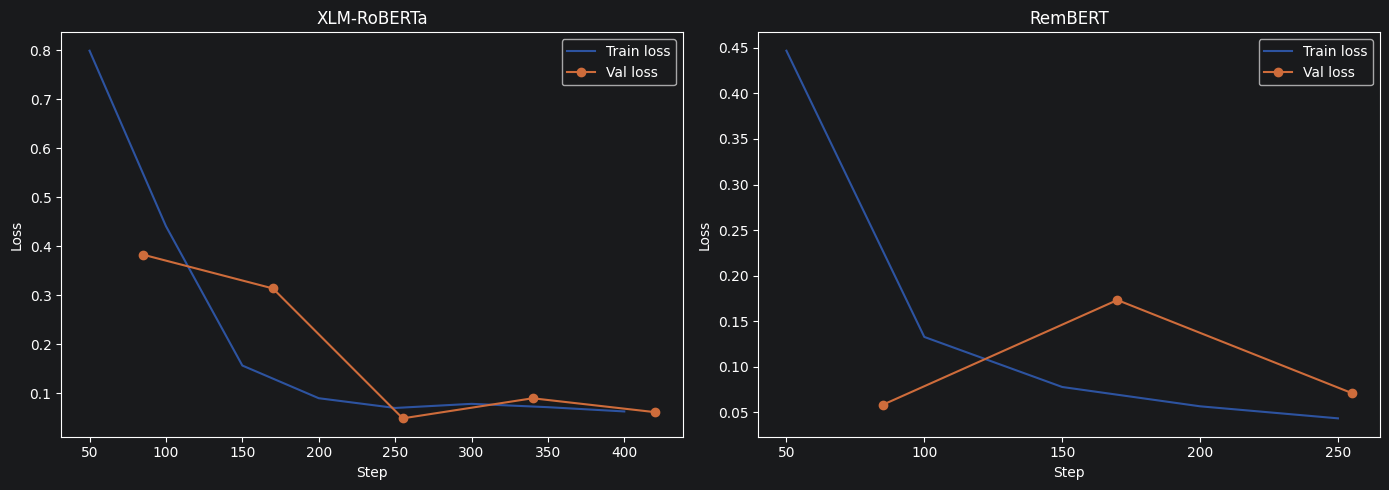

Loss curves saved.


In [14]:
import matplotlib.pyplot as plt

def extract_loss_curve(trainer: Trainer):
    log = trainer.state.log_history
    train_steps, train_loss = [], []
    val_steps, val_loss = [], []
    for entry in log:
        if 'loss' in entry and 'eval_loss' not in entry:
            train_steps.append(entry['step'])
            train_loss.append(entry['loss'])
        if 'eval_loss' in entry:
            val_steps.append(entry['step'])
            val_loss.append(entry['eval_loss'])
    return train_steps, train_loss, val_steps, val_loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, trainer, title in zip(axes, [xlmr_trainer, rembert_trainer], ['XLM-RoBERTa', 'RemBERT']):
    ts, tl, vs, vl = extract_loss_curve(trainer)
    ax.plot(ts, tl, label='Train loss', alpha=0.7)
    ax.plot(vs, vl, label='Val loss', marker='o')
    ax.set_title(title)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/discriminative_loss_curves.png', dpi=150)
plt.show()
print('Loss curves saved.')

## 8. Summary Table

In [15]:
import json

summary = pd.DataFrame([
    {
        'Model': 'xlm-roberta-base',
        'Accuracy': xlmr_metrics['accuracy'],
        'Macro-F1': xlmr_metrics['macro_f1'],
        **{f'F1-{k}': v for k, v in xlmr_metrics['per_class_f1'].items()},
    },
    {
        'Model': 'google/rembert',
        'Accuracy': rembert_metrics['accuracy'],
        'Macro-F1': rembert_metrics['macro_f1'],
        **{f'F1-{k}': v for k, v in rembert_metrics['per_class_f1'].items()},
    },
])
display(summary.round(4))

with open('../data/processed/discriminative_results.json', 'w') as f:
    json.dump({'xlmr': xlmr_metrics, 'rembert': rembert_metrics}, f, indent=2)
print('Results saved to data/processed/discriminative_results.json')

,Model,Accuracy,Macro-F1,F1-false,F1-partially_true,F1-true
0,xlm-roberta-base,0.9822,0.6591,0.9840,0.0,0.9933
1,google/rembert,0.9882,0.6631,0.9894,0.0,1.0000


Results saved to data/processed/discriminative_results.json


## 9. Save Raw Predictions for Confusion Matrix (Notebook 05)

In [16]:
# Save raw test-set predictions so Notebook 05 can plot confusion matrices
# for the discriminative models alongside the generative ones.
xlmr_pred_df = test_df[['claim_id', 'claim_text', 'veracity_label']].copy().reset_index(drop=True)
xlmr_pred_df['pred_label'] = xlmr_preds[:len(xlmr_pred_df)]
xlmr_pred_df.to_csv('../data/processed/test_with_xlmr_preds.csv', index=False, encoding='utf-8')

rembert_pred_df = test_df[['claim_id', 'claim_text', 'veracity_label']].copy().reset_index(drop=True)
rembert_pred_df['pred_label'] = rembert_preds[:len(rembert_pred_df)]
rembert_pred_df.to_csv('../data/processed/test_with_rembert_preds.csv', index=False, encoding='utf-8')

print('XLM-RoBERTa predictions saved -> test_with_xlmr_preds.csv')
print('RemBERT predictions saved     -> test_with_rembert_preds.csv')

XLM-RoBERTa predictions saved -> test_with_xlmr_preds.csv
RemBERT predictions saved     -> test_with_rembert_preds.csv
